In [1]:
# ============================================================
# CELL A: RECORDED RESULTS (hardcoded — session disconnected,
# these are transcribed exactly from each stage's printed output)
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = '/content/drive/MyDrive/semeval_august27neil_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

RESULTS_DIR = os.path.join(OUTPUT_DIR, 'full_pipeline_results')
os.makedirs(RESULTS_DIR, exist_ok=True)

# Stage -> {success@1, success@5, success@10}
# Recorded from live cell outputs across both notebooks (27engneilfinal.ipynb + Eng_resume.ipynb)
pipeline_results = {
    'Frozen ME5-Large':                    {'success@1': 0.434, 'success@5': 0.716, 'success@10': 0.788},
    'Fine-tuned ME5-Large (LoRA)':          {'success@1': 0.418, 'success@5': 0.728, 'success@10': 0.810},
    'Ensemble (alpha=0.65)':                {'success@1': 0.440, 'success@5': 0.750, 'success@10': 0.824},
    'Ensemble (alpha=0.20, re-tuned)':      {'success@1': 0.476, 'success@5': 0.766, 'success@10': 0.834},
    'Ensemble + CE Rerank (beta=1.00)':     {'success@1': 0.440, 'success@5': 0.782, 'success@10': 0.860},
}

STAGE_ORDER = list(pipeline_results.keys())
METRICS = ['success@1', 'success@5', 'success@10']

print('Loaded recorded results for', len(pipeline_results), 'pipeline stages.')

Mounted at /content/drive
Loaded recorded results for 5 pipeline stages.


In [2]:
# ============================================================
# CELL B: BUILD + SAVE COMPARISON TABLE (CSV + Markdown)
# ============================================================
results_df = pd.DataFrame(pipeline_results).T[METRICS]
results_df.index.name = 'Stage'

print(results_df.round(4).to_string())

# Improvement of every stage vs the frozen baseline
baseline = results_df.loc['Frozen ME5-Large']
improvement = results_df.subtract(baseline, axis=1)
pct_improvement = improvement.divide(baseline, axis=1) * 100

results_df.to_csv(os.path.join(RESULTS_DIR, 'full_pipeline_comparison.csv'))

with open(os.path.join(RESULTS_DIR, 'full_pipeline_comparison.md'), 'w') as f:
    f.write('# English Monolingual Retrieval — Full Pipeline Results\n\n')
    f.write(results_df.round(4).to_markdown())
    f.write('\n\n## Improvement vs. Frozen Baseline\n\n')
    for stage in STAGE_ORDER[1:]:
        f.write(f'\n**{stage}**\n\n')
        for m in METRICS:
            f.write(f'- {m}: {improvement.loc[stage, m]:+.4f} ({pct_improvement.loc[stage, m]:+.2f}%)\n')

print(f'\nSaved table to: {RESULTS_DIR}/full_pipeline_comparison.csv')
print(f'Saved table to: {RESULTS_DIR}/full_pipeline_comparison.md')

                                  success@1  success@5  success@10
Stage                                                             
Frozen ME5-Large                      0.434      0.716       0.788
Fine-tuned ME5-Large (LoRA)           0.418      0.728       0.810
Ensemble (alpha=0.65)                 0.440      0.750       0.824
Ensemble (alpha=0.20, re-tuned)       0.476      0.766       0.834
Ensemble + CE Rerank (beta=1.00)      0.440      0.782       0.860

Saved table to: /content/drive/MyDrive/semeval_august27neil_results/full_pipeline_results/full_pipeline_comparison.csv
Saved table to: /content/drive/MyDrive/semeval_august27neil_results/full_pipeline_results/full_pipeline_comparison.md


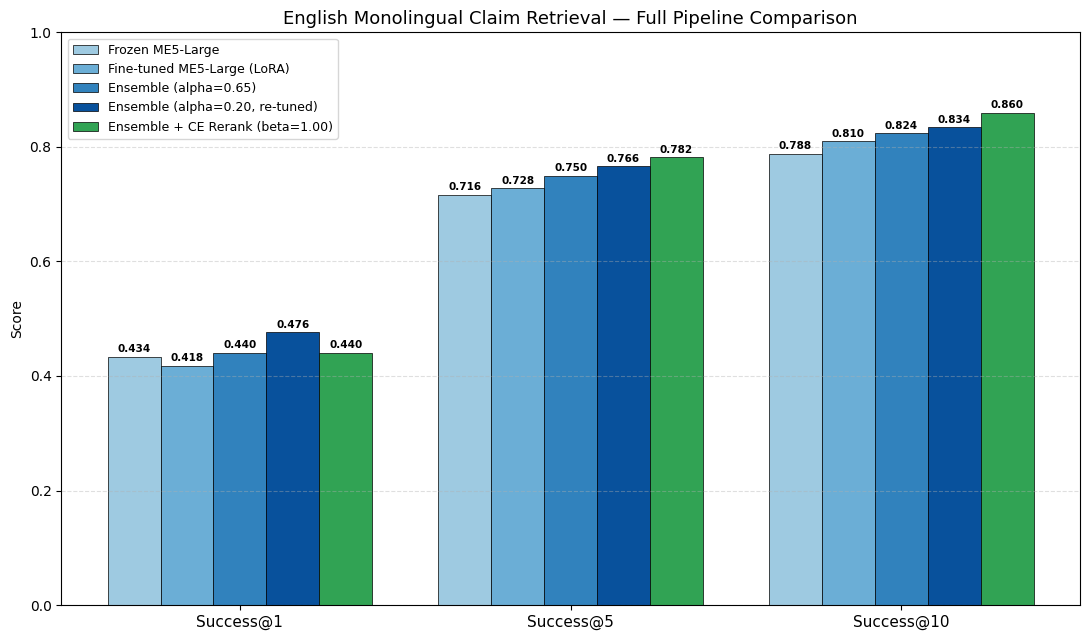

Saved chart to: /content/drive/MyDrive/semeval_august27neil_results/full_pipeline_results/full_pipeline_bar_chart.png


In [3]:
# ============================================================
# CELL C: GROUPED BAR CHART — ALL STAGES x ALL METRICS
# ============================================================
x = np.arange(len(METRICS))
n_stages = len(STAGE_ORDER)
width = 0.8 / n_stages
colors = ['#9ECAE1', '#6BAED6', '#3182BD', '#08519C', '#31A354']

fig, ax = plt.subplots(figsize=(11, 6.5))
for i, stage in enumerate(STAGE_ORDER):
    vals = [pipeline_results[stage][m] for m in METRICS]
    offset = (i - (n_stages - 1) / 2) * width
    bars = ax.bar(x + offset, vals, width, label=stage, color=colors[i], edgecolor='black', linewidth=0.5)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.008, f'{h:.3f}',
                ha='center', fontsize=7.5, fontweight='bold', rotation=0)

ax.set_xticks(x)
ax.set_xticklabels(['Success@1', 'Success@5', 'Success@10'], fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.set_title('English Monolingual Claim Retrieval — Full Pipeline Comparison', fontsize=13)
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
bar_chart_path = os.path.join(RESULTS_DIR, 'full_pipeline_bar_chart.png')
plt.savefig(bar_chart_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved chart to: {bar_chart_path}')

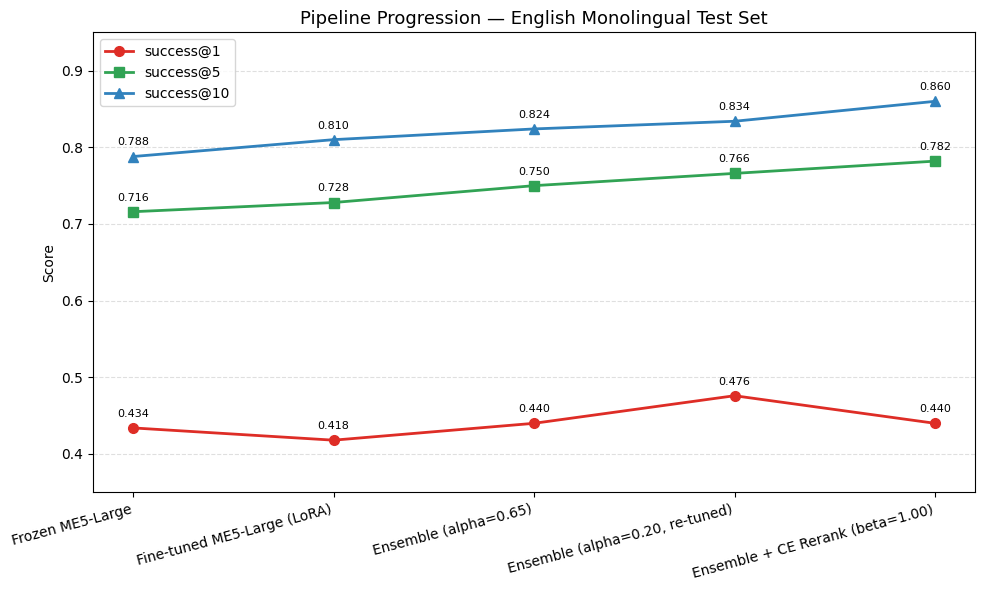

Saved chart to: /content/drive/MyDrive/semeval_august27neil_results/full_pipeline_results/pipeline_progression_chart.png


In [4]:
# ============================================================
# CELL D: PIPELINE PROGRESSION CHART (line, all 3 metrics vs stage)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
markers = ['o', 's', '^']
metric_colors = ['#DE2D26', '#31A354', '#3182BD']

for m, marker, color in zip(METRICS, markers, metric_colors):
    vals = [pipeline_results[stage][m] for stage in STAGE_ORDER]
    ax.plot(STAGE_ORDER, vals, marker=marker, color=color, linewidth=2, markersize=7, label=m)
    for xi, yi in zip(STAGE_ORDER, vals):
        ax.annotate(f'{yi:.3f}', (xi, yi), textcoords="offset points", xytext=(0, 8),
                    ha='center', fontsize=8)

ax.set_ylim(0.35, 0.95)
ax.set_ylabel('Score')
ax.set_title('Pipeline Progression — English Monolingual Test Set', fontsize=13)
ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.setp(ax.get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
progression_chart_path = os.path.join(RESULTS_DIR, 'pipeline_progression_chart.png')
plt.savefig(progression_chart_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved chart to: {progression_chart_path}')

In [5]:
# ============================================================
# CELL E: SAVE RAW RESULTS DICT AS JSON (backup, in case CSV/MD
# formatting ever needs to be regenerated without re-deriving numbers)
# ============================================================
with open(os.path.join(RESULTS_DIR, 'full_pipeline_results_raw.json'), 'w') as f:
    json.dump(pipeline_results, f, indent=2)
print(f'Saved raw results to: {RESULTS_DIR}/full_pipeline_results_raw.json')

Saved raw results to: /content/drive/MyDrive/semeval_august27neil_results/full_pipeline_results/full_pipeline_results_raw.json
